# Solar Filament Segmentation Challenge 2026 -- MVP1 (Kaggle GPU)

Clones the `jp-mvp1` branch of the repo and drives the same `src/train.py` /
`src/infer.py` / `src/submission.py` used locally -- logic lives in one place (the
repo), not duplicated into notebook cells. Local training on a Mac (MPS/CPU) is slow
enough to matter for MVP1 iteration speed; this notebook exists to run the identical
pipeline on a real GPU instead.

MVP1 is not about score -- see `MVP1_PLAN.md` section 0. The goal here is: train the
tiny U-Net faster, produce a validated `submission.csv`, and compare local PQ against
the leaderboard once uploaded.


### 0. Clone the repo

Requires the `jp-mvp1` branch to already be pushed to `origin` -- if this clone
fails with "Remote branch jp-mvp1 not found", push it from local first.


In [1]:
!git clone -b jp-mvp1 https://github.com/jprakash-1/Solar-Filament-Segmentation.git


Cloning into 'Solar-Filament-Segmentation'...
remote: Enumerating objects: 336, done.
remote: Counting objects: 100% (336/336), done.
remote: Compressing objects: 100% (238/238), done.
remote: Total 336 (delta 188), reused 235 (delta 90), pack-reused 0 (from 0)
Receiving objects: 100% (336/336), 2.69 MiB | 11.25 MiB/s, done.
Resolving deltas: 100% (188/188), done.


In [2]:
%cd Solar-Filament-Segmentation
!ls


/kaggle/working/Solar-Filament-Segmentation
 configs        README.md
 data	        requirements.txt
 kaggle.md      scripts
 memory.md     'Solar Filament Segmentation Challenge 2026.code-workspace'
 MVP1_PLAN.md   src
 notebooks      train_mvp1_kaggle.ipynb
 outputs


In [3]:
# re-run-safe: pick up any commits pushed after the kernel started
!git pull origin jp-mvp1


From https://github.com/jprakash-1/Solar-Filament-Segmentation
 * branch            jp-mvp1    -> FETCH_HEAD
Already up to date.


### 1. Install dependencies + confirm GPU

In [4]:
!pip install -q -r requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.5 MB/s eta 0:00:00 0:00:01


In [5]:
import torch
print("torch", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))


torch 2.10.0+cu128
cuda available: True
device: Tesla T4


### 2. Locate the mounted data

Auto-detects the competition data under `/kaggle/input` by globbing for the
annotation json rather than hardcoding the dataset-mount folder name (which depends
on how the dataset was attached to this kernel) -- falls back to the local `data/raw`
layout so this same cell works when the notebook is run outside Kaggle too.


In [6]:
!find /kaggle/input -maxdepth 4 2>/dev/null || echo "(not running on Kaggle -- /kaggle/input doesn't exist)"


/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/filament-segmentation-2026
/kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026
/kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026/test
/kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026/train


In [7]:
import glob
from pathlib import Path

if Path("/kaggle/input").exists():
    matches = glob.glob("/kaggle/input/**/MAGFiLO_1.0_Annotations_kaggle2026_train.json", recursive=True)
    assert matches, "Could not find the training annotation json under /kaggle/input -- check the attached dataset and adjust this cell."
    DATA_JSON = Path(matches[0])
    TRAIN_IMAGES_DIR = DATA_JSON.parent / "train_images"
    TEST_IMAGES_DIR = DATA_JSON.parent.parent / "test" / "test_images"
else:
    DATA_JSON = Path("data/raw/MAGFiLO_1.0_Kaggle_2026/train/MAGFiLO_1.0_Annotations_kaggle2026_train.json")
    TRAIN_IMAGES_DIR = Path("data/raw/MAGFiLO_1.0_Kaggle_2026/train/train_images")
    TEST_IMAGES_DIR = Path("data/raw/MAGFiLO_1.0_Kaggle_2026/test/test_images")

print("DATA_JSON:", DATA_JSON, "exists:", DATA_JSON.exists())
print("TRAIN_IMAGES_DIR:", TRAIN_IMAGES_DIR, "exists:", TRAIN_IMAGES_DIR.exists())
print("TEST_IMAGES_DIR:", TEST_IMAGES_DIR, "exists:", TEST_IMAGES_DIR.exists())
assert DATA_JSON.exists() and TRAIN_IMAGES_DIR.exists() and TEST_IMAGES_DIR.exists(), \
    "adjust the path-detection logic above to match this dataset's actual mount layout"


DATA_JSON: /kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026/train/MAGFiLO_1.0_Annotations_kaggle2026_train.json exists: True
TRAIN_IMAGES_DIR: /kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026/train/train_images exists: True
TEST_IMAGES_DIR: /kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026/test/test_images exists: True


### 3. Train

GPU affords a bigger batch size and more epochs than the local MPS defaults (see
`configs/mvp1_kaggle.yaml` for the reasoning) -- override via CLI flags, nothing here
is hardcoded into `src/train.py` itself.


In [8]:
!torchrun --nproc_per_node=$(python -c "import torch; print(max(1, torch.cuda.device_count()))") -m src.train \
    --data-json "{DATA_JSON}" \
    --images-dir "{TRAIN_IMAGES_DIR}" \
    --img-size 256 \
    --epochs 30 \
    --batch-size 32 \
    --checkpoint-out outputs/checkpoints/mvp1_unet_kaggle.pt \
    --log-csv outputs/logs/train_log_kaggle.csv


W0829 13:22:30.274000 133 torch/distributed/run.py:852] 
W0829 13:22:30.274000 133 torch/distributed/run.py:852] *****************************************
W0829 13:22:30.274000 133 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0829 13:22:30.274000 133 torch/distributed/run.py:852] *****************************************
Using device: cuda:0  (distributed, world_size=2)loading annotations into memory...

loading annotations into memory...
Done (t=0.77s)
creating index...
index created!
Done (t=0.78s)
creating index...
loading annotations into memory...
index created!
train: 973 images, val: 181 images (grouped by file_name)
loading annotations into memory...
Done (t=0.42s)
creating index...
index created!
loading annotations into memory...
Done (t=0.42s)
creating index...
index created!
loadin

### 4. Training curve

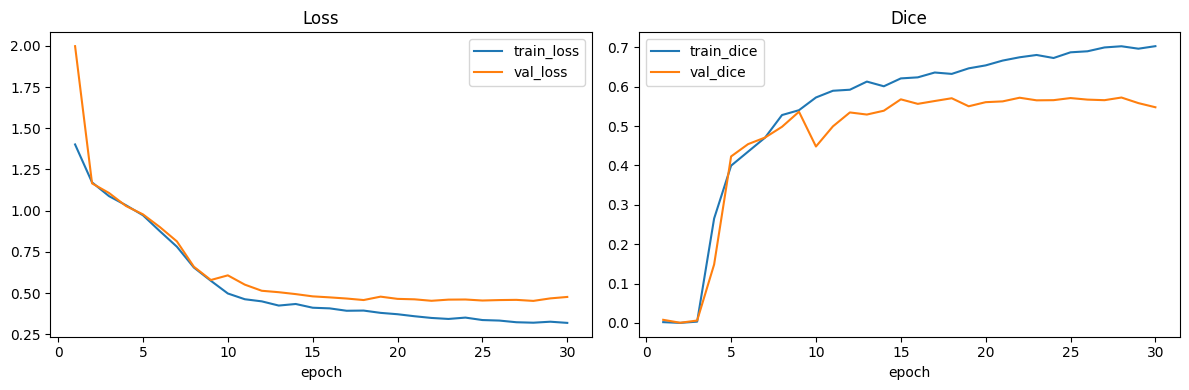

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv("outputs/logs/train_log_kaggle.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(log["epoch"], log["train_loss"], label="train_loss")
axes[0].plot(log["epoch"], log["val_loss"], label="val_loss")
axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].set_title("Loss")
axes[1].plot(log["epoch"], log["train_dice"], label="train_dice")
axes[1].plot(log["epoch"], log["val_dice"], label="val_dice")
axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].set_title("Dice")
fig.tight_layout()
plt.show()


### 5. Local validation (Panoptic Quality + Dice)

Runs the full inference + postprocessing pipeline against the held-out
`file_name`-grouped val split -- the same instance-splitting logic used for the real
submission -- as a local sanity check before spending one of the 5 daily submission
slots.


In [10]:
!python -m src.infer \
    --checkpoint outputs/checkpoints/mvp1_unet_kaggle.pt \
    --split val \
    --data-json "{DATA_JSON}" \
    --train-images-dir "{TRAIN_IMAGES_DIR}"


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/kaggle/working/Solar-Filament-Segmentation/src/infer.py", line 154, in <module>
    main()
  File "/kaggle/working/Solar-Filament-Segmentation/src/infer.py", line 143, in main
    model, ckpt = load_model(args.checkpoint, device)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/Solar-Filament-Segmentation/src/infer.py", line 77, in load_model
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1500, in load
    with _open_file_like(f, "rb") as opened_file:
         ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 768, in _open_file_like
    return _open_file(name_or_buffer, m

### 6. Inference -> submission.csv

Predicts on the real test set, splits into filament instances (resize-then-threshold-
then-connected-components, `src/postprocess.py`), RLE-encodes each one, and writes
`filament_id,segmentation_rle` rows.


In [11]:
!python -m src.infer \
    --checkpoint outputs/checkpoints/mvp1_unet_kaggle.pt \
    --split test \
    --test-images-dir "{TEST_IMAGES_DIR}" \
    --out outputs/submissions/mvp1_unet_kaggle.csv


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/kaggle/working/Solar-Filament-Segmentation/src/infer.py", line 154, in <module>
    main()
  File "/kaggle/working/Solar-Filament-Segmentation/src/infer.py", line 143, in main
    model, ckpt = load_model(args.checkpoint, device)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/Solar-Filament-Segmentation/src/infer.py", line 77, in load_model
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1500, in load
    with _open_file_like(f, "rb") as opened_file:
         ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 768, in _open_file_like
    return _open_file(name_or_buffer, m

In [12]:
!python -m src.submission --validate outputs/submissions/mvp1_unet_kaggle.csv --test-images-dir "{TEST_IMAGES_DIR}"


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/kaggle/working/Solar-Filament-Segmentation/src/submission.py", line 106, in <module>
    main()
  File "/kaggle/working/Solar-Filament-Segmentation/src/submission.py", line 93, in main
    result = validate_submission(args.validate, expected_image_stems=expected_stems)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/Solar-Filament-Segmentation/src/submission.py", line 46, in validate_submission
    df = pd.read_csv(csv_path, dtype={"filament_id": str, "segmentation_rle": str}, keep_default_na=False)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^

### 7. Stage for one-click Kaggle submission

Copies the validated CSV to `/kaggle/working/submission.csv` -- Kaggle's convention
for "Submit to competition" directly from a notebook's output.


In [13]:
import shutil

shutil.copy("outputs/submissions/mvp1_unet_kaggle.csv", "/kaggle/working/submission.csv")
pd.read_csv("/kaggle/working/submission.csv").head()


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/submissions/mvp1_unet_kaggle.csv'

### Outputs

- `outputs/checkpoints/mvp1_unet_kaggle.pt` -- model weights
- `outputs/logs/train_log_kaggle.csv` -- per-epoch train/val loss + Dice
- `outputs/submissions/mvp1_unet_kaggle.csv` / `/kaggle/working/submission.csv` --
  ready to submit
- Local PQ printed in section 5 -- compare against the leaderboard PQ after
  submitting; a large gap flags a bug in local metric computation or the
  train/val split, not necessarily a bad model (`MVP1_PLAN.md` section 4, day 2 step 8).
